<a href="https://colab.research.google.com/github/OlaJTC/Assignment-12/blob/main/Ola_Mohammad_GitHub12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 12: Neural Network and Deep Learning Basics**

# **1. Setup and dataset loading (CIFAR‑10 example)**

In [ ]:
# Install / import basics
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
Train shape: (50000, 32, 32, 3) Test shape: (10000, 32, 32, 3)


# **2. Visualize sample images**

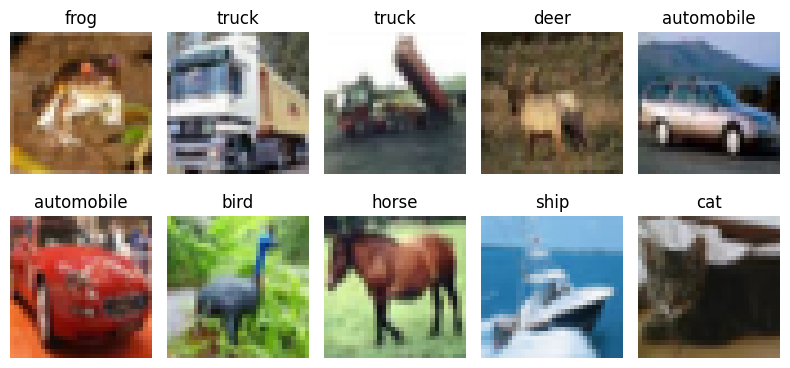

In [ ]:
# Show a few samples
plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()


# **3. Preprocessing (normalization + one‑hot labels)**

In [ ]:
# Normalize to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# Flatten images for feedforward NN
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test, num_classes=10)


# **4. Simple feedforward neural network**

In [ ]:
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(X_train_flat.shape[1],)))
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

# **5. Training with validation**

In [ ]:
history = model.fit(
    X_train_flat, y_train_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - accuracy: 0.3174 - loss: 1.8980 - val_accuracy: 0.3618 - val_loss: 1.7680
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.3913 - loss: 1.6974 - val_accuracy: 0.4027 - val_loss: 1.6823
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4297 - loss: 1.6055 - val_accuracy: 0.4297 - val_loss: 1.6187
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.4479 - loss: 1.5475 - val_accuracy: 0.4394 - val_loss: 1.5922
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.4603 - loss: 1.5075 - val_accuracy: 0.4523 - val_loss: 1.5624
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.4755 - loss: 1.4768 - val_accuracy: 0.4584 - val_loss: 1.5240
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.4845 - loss: 1.4448 - val_accuracy: 0.4670 - val_loss: 1.5105
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.4919 - loss: 1.4191 - 

# **6. Training/validation curves**

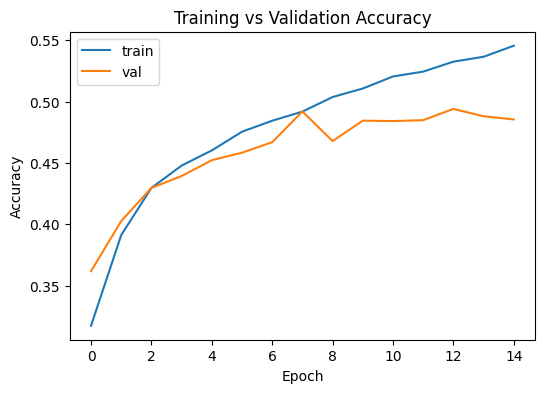

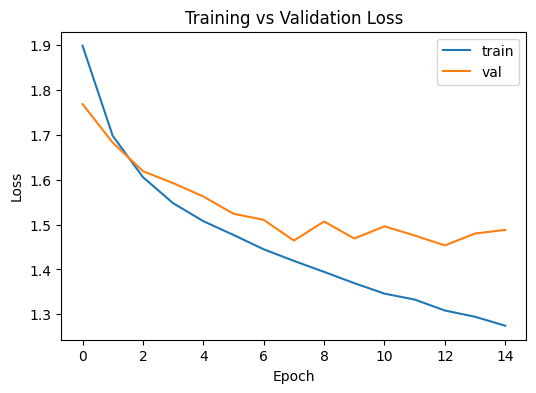

In [ ]:
# Accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

# Loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

# **7. Model evaluation (accuracy, precision, recall, F1, confusion matrix)**

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
Accuracy:  0.4868
Precision: 0.5006
Recall:    0.4868
F1-score:  0.4823

Classification Report:

              precision    recall  f1-score   support

    airplane       0.65      0.44      0.52      1000
  automobile       0.53      0.67      0.59      1000
        bird       0.36      0.40      0.38      1000
         cat       0.37      0.30      0.33      1000
        deer       0.45      0.40      0.42      1000
         dog       0.49      0.33      0.39      1000
        frog       0.41      0.69      0.51      1000
       horse       0.68      0.44      0.54      1000
        ship       0.60      0.66      0.63      1000
       truck       0.48      0.54      0.51      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.48     10000
weighted avg       0.50      0.49      0.48     10000



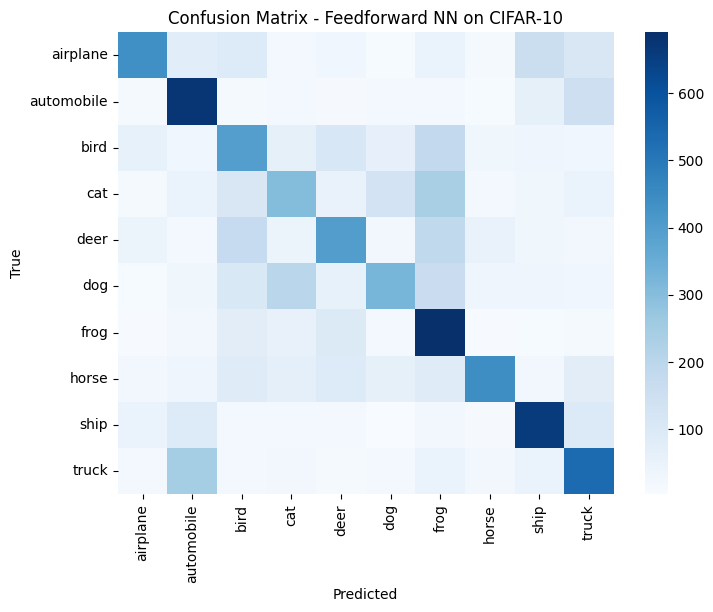

In [ ]:
# Predict on test set
y_pred_prob = model.predict(X_test_flat)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.flatten()

# Metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec  = recall_score(y_true, y_pred, average='macro')
f1   = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Feedforward NN on CIFAR-10')
plt.show()


# **8. Optional: data augmentation (for later experiments)**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

# Example augmented training (for CNN or reshaped FFN)
# model.fit(datagen.flow(X_train_flat.reshape(-1,32,32,3), y_train_cat, batch_size=64),
#           epochs=15,
#           validation_data=(X_test_flat.reshape(-1,32,32,3), y_test_cat))


In [2]:
!git clone https://github.com/OlaJTC/Assignment-12

Cloning into 'Assignment-12'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 137.91 KiB | 1.86 MiB/s, done.


In [5]:
!git config --global user.email "jariryola@gmail.com"
!git config --global user.name "OlaJTC"

In [6]:
%cd /content/assignment-12
!git add .
!git commit -m "Assignment 12 Submission"
!git push origin main


[Errno 2] No such file or directory: '/content/assignment-12'
/content/Assignment-12
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address
